# Clustering Analysis — 25 Known Books
Applies six clustering algorithms to the feature representations produced by `Feature Vector.ipynb`,
then evaluates each configuration using silhouette score, Cohen's Kappa, and topic coherence (LDA only).

**Run order:** `Book partitioner.ipynb` → `Feature Vector.ipynb` → **`Clustering.ipynb`**

**Algorithms:** K-Means · Divisive Hierarchical (Bisecting K-Means) · LDA · GMM · SOM · DEC

**Feature sets:** BOW · TF-IDF · TF-IDF-PCA50 · Stylometric · LMF · Stylo+LMF · Stylo+LMF-15 · SBERT · SBERT-PCA50

In [2]:
import os, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import LatentDirichletAllocation, PCA
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import silhouette_score, cohen_kappa_score
from sklearn.preprocessing import StandardScaler, normalize

import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

print('All imports successful.')

All imports successful.


## Configuration and Feature Loading
Loads `TestingData/partitions.csv` and all feature representations saved by `Feature Vector.ipynb`.

`Stylo+LMF-15` is built using the top-15 features selected by mutual information in `Feature Vector.ipynb`
and saved to `FeatureTrainingData/selected_stylo_lmf_features.json`.

In [3]:
import json as _json

PARTITIONS_CSV = 'TestingData/partitions.csv'
FEAT_DIR       = 'FeatureTrainingData'
IMAGES_DIR     = 'images'
GENRES         = ['biography', 'fantasy', 'horror', 'romance', 'sci-fi']
N_CLUSTERS     = 5
RANDOM_STATE   = 42
os.makedirs(IMAGES_DIR, exist_ok=True)

partitions = pd.read_csv(PARTITIONS_CSV)
X_text   = partitions['text'].tolist()
y_true   = partitions['genre'].tolist()
part_ids = partitions['partition_id'].tolist()

print(f'Partitions loaded: {len(partitions):,}')
print(partitions['genre'].value_counts().to_string())

def _load_feat(path):
    df = pd.read_csv(path)
    drop = {'partition_id', 'book', 'genre'}
    cols = [c for c in df.columns if c not in drop]
    return df[cols].values.astype(np.float32)

print('\nLoading feature sets...')
tfidf_path = f'{FEAT_DIR}/tfidf_features.csv'
if not os.path.exists(tfidf_path):
    tfidf_path = f'{FEAT_DIR}/featurevector.csv'
X_tfidf     = _load_feat(tfidf_path)
X_bow       = _load_feat(f'{FEAT_DIR}/bow_features.csv')
X_stylo     = StandardScaler().fit_transform(_load_feat(f'{FEAT_DIR}/stylometric_features.csv'))
X_lmf       = StandardScaler().fit_transform(_load_feat(f'{FEAT_DIR}/lmf_features.csv'))
X_stylo_lmf = np.hstack([X_stylo, X_lmf])

X_tfidf_pca = PCA(n_components=50, random_state=RANDOM_STATE).fit_transform(X_tfidf)

# SBERT — fall back to TF-IDF PCA if embeddings were not generated
npy_path = f'{FEAT_DIR}/sbert_features.npy'
csv_path = f'{FEAT_DIR}/sbert_features.csv'
if os.path.exists(npy_path):
    X_sbert = np.load(npy_path).astype(np.float32)
    print('  SBERT          : loaded from .npy')
elif os.path.exists(csv_path):
    X_sbert = _load_feat(csv_path)
    print('  SBERT          : loaded from .csv')
else:
    X_sbert = X_tfidf_pca.copy()
    print('  SBERT          : NOT FOUND — falling back to TF-IDF-PCA50')

X_sbert_pca = PCA(n_components=50, random_state=RANDOM_STATE).fit_transform(X_sbert)

# Stylo+LMF-15: top-15 features selected by MI + correlation filter (Feature Vector.ipynb)
_sel_path = f'{FEAT_DIR}/selected_stylo_lmf_features.json'
if os.path.exists(_sel_path):
    with open(_sel_path) as _f:
        _sel_feats = _json.load(_f)
    _meta   = {'partition_id', 'book', 'genre'}
    _s_df   = pd.read_csv(f'{FEAT_DIR}/stylometric_features.csv')
    _l_df   = pd.read_csv(f'{FEAT_DIR}/lmf_features.csv')
    _s_cols = [c for c in _s_df.columns if c not in _meta]
    _l_cols = [c for c in _l_df.columns if c not in _meta]
    _all_f  = _s_cols + _l_cols
    _X_raw  = np.hstack([_s_df[_s_cols].values, _l_df[_l_cols].values])
    _idx15  = [_all_f.index(f) for f in _sel_feats if f in _all_f]
    X_stylo_lmf_sel = StandardScaler().fit_transform(_X_raw[:, _idx15].astype(np.float32))
    print(f'  Stylo+LMF-15   : {X_stylo_lmf_sel.shape}  ({len(_sel_feats)} selected features)')
else:
    X_stylo_lmf_sel = X_stylo_lmf
    print('  Stylo+LMF-15   : selection file not found — using full 19 features')

for name, X in [('TF-IDF', X_tfidf), ('BOW', X_bow), ('Stylometric', X_stylo),
                ('LMF', X_lmf), ('Stylo+LMF', X_stylo_lmf), ('Stylo+LMF-15', X_stylo_lmf_sel),
                ('SBERT', X_sbert), ('SBERT-PCA50', X_sbert_pca)]:
    print(f'  {name:14}: {X.shape}')

ALL_FEATURES = {
    'BOW':           X_bow,
    'TF-IDF':        X_tfidf,
    'Stylometric':   X_stylo,
    'LMF':           X_lmf,
    'Stylo+LMF':     X_stylo_lmf,
    'Stylo+LMF-15':  X_stylo_lmf_sel,
    'SBERT':         X_sbert,
    'TF-IDF-PCA50':  X_tfidf_pca,
    'SBERT-PCA50':   X_sbert_pca,
}
print('\nALL_FEATURES:', list(ALL_FEATURES.keys()))

Partitions loaded: 5,000
genre
biography    1000
fantasy      1000
horror       1000
romance      1000
sci-fi       1000

Loading feature sets...
  SBERT          : loaded from .npy
  Stylo+LMF-15   : (5000, 15)  (15 selected features)
  TF-IDF        : (5000, 1026)
  BOW           : (5000, 1026)
  Stylometric   : (5000, 10)
  LMF           : (5000, 9)
  Stylo+LMF     : (5000, 19)
  Stylo+LMF-15  : (5000, 15)
  SBERT         : (5000, 384)
  SBERT-PCA50   : (5000, 50)

ALL_FEATURES: ['BOW', 'TF-IDF', 'Stylometric', 'LMF', 'Stylo+LMF', 'Stylo+LMF-15', 'SBERT', 'TF-IDF-PCA50', 'SBERT-PCA50']


## Helper Functions
Shared utilities for mapping cluster IDs to genre labels and computing evaluation metrics.

In [4]:
def map_clusters(y_true, y_pred):
    # Map each cluster to its majority genre label.
    arr = np.array(y_true)
    mapping = {cid: Counter(arr[y_pred == cid]).most_common(1)[0][0]
               for cid in np.unique(y_pred) if (y_pred == cid).sum() > 0}
    return np.array([mapping.get(p, 'unknown') for p in y_pred]), mapping

def evaluate(X, y_true, y_pred):
    # Return (silhouette, kappa) for the given clustering.
    X_e = X if X.shape[1] <= 50 else PCA(n_components=50, random_state=42).fit_transform(X)
    try:
        sil = float(silhouette_score(X_e, y_pred,
                                     sample_size=min(2000, len(y_pred)),
                                     random_state=42))
    except Exception:
        sil = float('nan')
    mapped, _ = map_clusters(y_true, y_pred)
    kap = float(cohen_kappa_score(y_true, mapped))
    return sil, kap

all_results = []   # list of result dicts
all_preds   = []   # (y_pred_raw, y_pred_mapped) in same order as all_results
print('Helpers defined.')

Helpers defined.


In [5]:
# Top-5 feature sets for non-LDA algorithms (ranked by silhouette in Feature Vector.ipynb)
import json as _json
_rank_path = f'{FEAT_DIR}/top_features_ranked.json'
if os.path.exists(_rank_path):
    with open(_rank_path) as _f:
        _ranked_names = _json.load(_f)
    _top5_names = [f for f in _ranked_names if f in ALL_FEATURES][:5]
    print(f'Top 5 features (Feature Vector.ipynb silhouette ranking): {_top5_names}')
else:
    _top5_names = [k for k in ['SBERT-PCA50', 'SBERT', 'TF-IDF-PCA50', 'Stylo+LMF', 'Stylometric'] if k in ALL_FEATURES]
    print(f'Ranking file not found ? using fallback: {_top5_names}')

TOP5_FEATURES = {k: ALL_FEATURES[k] for k in _top5_names}
print('TOP5_FEATURES:', list(TOP5_FEATURES.keys()))


Top 5 features (Feature Vector.ipynb silhouette ranking): ['SBERT', 'TF-IDF-PCA50', 'Stylometric', 'Stylo+LMF', 'SBERT-PCA50']
TOP5_FEATURES: ['SBERT', 'TF-IDF-PCA50', 'Stylometric', 'Stylo+LMF', 'SBERT-PCA50']


## 1. K-Means Clustering
Centroid-based hard clustering with k = 5.
Assigns each partition to its nearest centroid by Euclidean distance, assuming spherical, equally-sized clusters.
Runs across all feature sets in `ALL_FEATURES`.

In [6]:
print(f'K-Means (top-3 features: {list(TOP5_FEATURES.keys())}):')
for feat_name, X in TOP5_FEATURES.items():
    km     = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=10)
    y_pred = km.fit_predict(X)
    sil, kap = evaluate(X, y_true, y_pred)
    mapped, _ = map_clusters(y_true, y_pred)
    all_results.append({'Algorithm': 'K-Means', 'Feature': feat_name,
                        'Silhouette': round(sil,4), 'Kappa': round(kap,4), 'Coherence': None})
    all_preds.append((y_pred, mapped))
    print(f'  {feat_name:14} -> Silhouette={sil:.4f}  Kappa={kap:.4f}')

K-Means (top-3 features: ['SBERT', 'TF-IDF-PCA50', 'Stylometric', 'Stylo+LMF', 'SBERT-PCA50']):
  SBERT          -> Silhouette=0.0716  Kappa=0.5753
  TF-IDF-PCA50   -> Silhouette=0.0529  Kappa=0.4677
  Stylometric    -> Silhouette=0.2061  Kappa=0.3227
  Stylo+LMF      -> Silhouette=0.1884  Kappa=0.2867
  SBERT-PCA50    -> Silhouette=0.0716  Kappa=0.5773


## 2. Divisive Hierarchical Clustering (Bisecting K-Means)
Top-down approach: starts with all data in one cluster and repeatedly bisects the largest cluster
using binary K-Means until k = 5 clusters are reached.
Unlike agglomerative methods, divisive clustering considers global structure at each split.
Runs across all feature sets in `ALL_FEATURES`.

In [7]:
def bisecting_kmeans(X, n_clusters=5, random_state=42):
    rng    = np.random.RandomState(random_state)
    labels = np.zeros(len(X), dtype=int)
    n_cur  = 1
    while n_cur < n_clusters:
        sizes  = np.bincount(labels, minlength=n_cur)
        target = int(np.argmax(sizes))
        mask   = labels == target
        if mask.sum() < 2:
            break
        km2  = KMeans(n_clusters=2, random_state=int(rng.randint(0, 9999)), n_init=5)
        sub  = km2.fit_predict(X[mask])
        labels[mask] = np.where(sub == 0, target, n_cur)
        n_cur += 1
    return labels

print(f'Divisive Hierarchical (top-3 features: {list(TOP5_FEATURES.keys())}):')
for feat_name, X in TOP5_FEATURES.items():
    y_pred = bisecting_kmeans(X, n_clusters=N_CLUSTERS, random_state=RANDOM_STATE)
    sil, kap = evaluate(X, y_true, y_pred)
    mapped, _ = map_clusters(y_true, y_pred)
    all_results.append({'Algorithm': 'Divisive Hierarchical', 'Feature': feat_name,
                        'Silhouette': round(sil,4), 'Kappa': round(kap,4), 'Coherence': None})
    all_preds.append((y_pred, mapped))
    print(f'  {feat_name:14} -> Silhouette={sil:.4f}  Kappa={kap:.4f}')

Divisive Hierarchical (top-3 features: ['SBERT', 'TF-IDF-PCA50', 'Stylometric', 'Stylo+LMF', 'SBERT-PCA50']):
  SBERT          -> Silhouette=0.0672  Kappa=0.5600
  TF-IDF-PCA50   -> Silhouette=0.0508  Kappa=0.4580
  Stylometric    -> Silhouette=0.1689  Kappa=0.2438
  Stylo+LMF      -> Silhouette=0.1106  Kappa=0.2422
  SBERT-PCA50    -> Silhouette=0.0673  Kappa=0.5585


## 3. LDA as Clustering
Latent Dirichlet Allocation models each partition as a probabilistic mixture of k = 5 latent topics.
LDA requires integer word counts (Dirichlet-Multinomial generative model) — TF-IDF is not suitable here.
Each partition is assigned to its dominant topic. Topic coherence (C_V) is computed via Gensim when available.

In [8]:
count_vec = CountVectorizer(max_features=5000, stop_words='english', min_df=2)
X_count   = count_vec.fit_transform(X_text)
lda_vocab = count_vec.get_feature_names_out()

lda = LatentDirichletAllocation(
    n_components=N_CLUSTERS, random_state=RANDOM_STATE,
    learning_method='batch', max_iter=50, n_jobs=-1
)
X_lda_probs = lda.fit_transform(X_count)
y_pred_lda  = np.argmax(X_lda_probs, axis=1)
sil_lda, kap_lda = evaluate(X_lda_probs, y_true, y_pred_lda)
mapped_lda, _    = map_clusters(y_true, y_pred_lda)

# Topic coherence via Gensim C_V score
coherence_score = None
try:
    from gensim.models.coherencemodel import CoherenceModel
    from gensim.corpora import Dictionary as GDict
    tok_texts = [[w.lower() for w in t.split() if w.isalpha() and len(w) > 2]
                 for t in X_text]
    gdict = GDict(tok_texts)
    topics_top = []
    for i in range(N_CLUSTERS):
        top_ids = lda.components_[i].argsort()[-10:][::-1]
        topics_top.append([lda_vocab[j] for j in top_ids])
    cm_obj = CoherenceModel(topics=topics_top, texts=tok_texts,
                            dictionary=gdict, coherence='c_v')
    coherence_score = round(cm_obj.get_coherence(), 4)
    print(f'LDA coherence (C_V): {coherence_score}')
except ImportError:
    print('gensim not installed — coherence skipped.  Run: pip install gensim')

all_results.append({'Algorithm': 'LDA', 'Feature': 'CountVec',
                    'Silhouette': round(sil_lda,4), 'Kappa': round(kap_lda,4),
                    'Coherence': coherence_score})
all_preds.append((y_pred_lda, mapped_lda))
print(f'  CountVec       -> Silhouette={sil_lda:.4f}  Kappa={kap_lda:.4f}  Coherence={coherence_score}')

print('\nLDA Topic -> Top 10 Words:')
for i in range(N_CLUSTERS):
    top_ids = lda.components_[i].argsort()[-10:][::-1]
    top_w   = [lda_vocab[j] for j in top_ids]
    dom_genre = Counter(np.array(y_true)[y_pred_lda == i]).most_common(1)[0][0] \
                if (y_pred_lda == i).sum() > 0 else '?'
    top_str = ', '.join(top_w)
    print(f'  Topic {i} ({dom_genre:10}): {top_str}')

LDA coherence (C_V): 0.4581
  CountVec       -> Silhouette=0.5494  Kappa=0.4275  Coherence=0.4581

LDA Topic -> Top 10 Words:
  Topic 0 (sci-fi    ): strong, tom, said, ship, dane, space, astro, sir, captain, ll
  Topic 1 (biography ): time, great, new, years, prince, people, men, royal, work, day
  Topic 2 (fantasy   ): said, alice, little, came, like, went, time, thought, way, did
  Topic 3 (romance   ): romeo, thou, shall, dorothy, love, come, thy, juliet, man, nurse
  Topic 4 (romance   ): mr, said, man, did, time, mrs, good, house, know, day


## 4. Gaussian Mixture Model (GMM)
Soft probabilistic clustering: fits a Gaussian distribution per cluster with its own covariance matrix.
Unlike K-Means (spherical clusters), GMM allows elliptical, overlapping clusters.
Features with dim > 100 are skipped — covariance estimation fails in very high dimensions.
Use the corresponding `-PCA50` variant for high-dimensional features (TF-IDF-PCA50, SBERT-PCA50).

In [9]:
print(f'GMM (top-3 features: {list(TOP5_FEATURES.keys())}):')
for feat_name, X in TOP5_FEATURES.items():
    if X.shape[1] > 100:
        print(f'  {feat_name:14} -> skipped (dim={X.shape[1]}, use {feat_name}-PCA50 instead)')
        continue
    X64 = X.astype(np.float64)
    cov = 'full' if X.shape[1] <= 50 else 'diag'
    try:
        gmm = GaussianMixture(n_components=N_CLUSTERS, random_state=RANDOM_STATE,
                              covariance_type=cov, n_init=3, reg_covar=1e-3)
        y_pred = gmm.fit_predict(X64)
    except Exception:
        gmm = GaussianMixture(n_components=N_CLUSTERS, random_state=RANDOM_STATE,
                              covariance_type='diag', n_init=3, reg_covar=1e-3)
        y_pred = gmm.fit_predict(X64)
    sil, kap = evaluate(X64, y_true, y_pred)
    mapped, _ = map_clusters(y_true, y_pred)
    all_results.append({'Algorithm': 'GMM', 'Feature': feat_name,
                        'Silhouette': round(sil, 4), 'Kappa': round(kap, 4), 'Coherence': None})
    all_preds.append((y_pred, mapped))
    print(f'  {feat_name:14} -> Silhouette={sil:.4f}  Kappa={kap:.4f}  [{cov}]')

GMM (top-3 features: ['SBERT', 'TF-IDF-PCA50', 'Stylometric', 'Stylo+LMF', 'SBERT-PCA50']):
  SBERT          -> skipped (dim=384, use SBERT-PCA50 instead)
  TF-IDF-PCA50   -> Silhouette=0.0466  Kappa=0.4768  [full]
  Stylometric    -> Silhouette=0.1114  Kappa=0.3020  [full]
  Stylo+LMF      -> Silhouette=0.1304  Kappa=0.2458  [full]
  SBERT-PCA50    -> Silhouette=0.0635  Kappa=0.7105  [full]


## 5. Self-Organizing Maps (SOM)
Unsupervised neural network that maps data onto a 2D grid while preserving topology.
Each data point's best-matching unit (BMU) is found on a 10×10 grid, then BMU weight vectors are clustered with K-Means.
Runs across all feature sets in `ALL_FEATURES`.

Requires `minisom`: `pip install minisom`

In [10]:
try:
    from minisom import MiniSom

    def run_som(X, n_clusters=5, grid=10, iters=2000, seed=42):
        X_n = normalize(X.astype(np.float32))
        som = MiniSom(grid, grid, X_n.shape[1], sigma=1.5, learning_rate=0.5,
                      neighborhood_function='gaussian', random_seed=seed)
        som.random_weights_init(X_n)
        som.train_random(X_n, iters, verbose=False)
        bmu_w = np.array([som.get_weights()[som.winner(x)] for x in X_n])
        km    = KMeans(n_clusters=n_clusters, random_state=seed, n_init=10)
        return km.fit_predict(bmu_w)

    print(f'SOM (top-3 features: {list(TOP5_FEATURES.keys())}):')
    for feat_name, X in TOP5_FEATURES.items():
        y_pred = run_som(X, n_clusters=N_CLUSTERS)
        sil, kap = evaluate(X, y_true, y_pred)
        mapped, _ = map_clusters(y_true, y_pred)
        all_results.append({'Algorithm': 'SOM', 'Feature': feat_name,
                            'Silhouette': round(sil,4), 'Kappa': round(kap,4), 'Coherence': None})
        all_preds.append((y_pred, mapped))
        print(f'  {feat_name:14} -> Silhouette={sil:.4f}  Kappa={kap:.4f}')

except ImportError:
    print('minisom not installed — skipping SOM.  Run: pip install minisom')

SOM (top-3 features: ['SBERT', 'TF-IDF-PCA50', 'Stylometric', 'Stylo+LMF', 'SBERT-PCA50']):
  SBERT          -> Silhouette=0.0247  Kappa=0.2670
  TF-IDF-PCA50   -> Silhouette=0.0034  Kappa=0.2482
  Stylometric    -> Silhouette=0.1052  Kappa=0.2562
  Stylo+LMF      -> Silhouette=0.0990  Kappa=0.2478
  SBERT-PCA50    -> Silhouette=0.0331  Kappa=0.3850


## 6. Deep Embedded Clustering (DEC)
Pre-trains a stacked autoencoder (256 → 128 → 32 latent dimensions) to learn a compressed representation,
then clusters in the 32-dimensional latent space using K-Means.
Runs across all feature sets in `ALL_FEATURES`.

Requires TensorFlow: `pip install tensorflow`

In [11]:
try:
    import tensorflow as tf
    from tensorflow import keras
    tf.get_logger().setLevel('ERROR')

    def build_autoencoder(in_dim, latent=32):
        inp = keras.Input(shape=(in_dim,))
        h   = keras.layers.Dense(256, activation='relu')(inp)
        h   = keras.layers.Dropout(0.2)(h)
        h   = keras.layers.Dense(128, activation='relu')(h)
        z   = keras.layers.Dense(latent, activation='relu', name='z')(h)
        d   = keras.layers.Dense(128, activation='relu')(z)
        d   = keras.layers.Dense(256, activation='relu')(d)
        out = keras.layers.Dense(in_dim, activation='linear')(d)
        return keras.Model(inp, out), keras.Model(inp, z)

    def run_dec(X, n_clusters=5, latent=32, epochs=30, seed=42):
        tf.random.set_seed(seed); np.random.seed(seed)
        X32 = X.astype(np.float32)
        lo, hi = X32.min(0), X32.max(0)
        rng = hi - lo; rng[rng == 0] = 1
        Xn  = (X32 - lo) / rng
        ae, enc = build_autoencoder(Xn.shape[1], latent)
        ae.compile(optimizer='adam', loss='mse')
        ae.fit(Xn, Xn, epochs=epochs, batch_size=256, verbose=0)
        Z  = enc.predict(Xn, verbose=0)
        km = KMeans(n_clusters=n_clusters, random_state=seed, n_init=10)
        return km.fit_predict(Z), Z

    print(f'DEC (top-3 features: {list(TOP5_FEATURES.keys())}):')
    for feat_name, X in TOP5_FEATURES.items():
        y_pred, Z = run_dec(X, n_clusters=N_CLUSTERS)
        sil, kap  = evaluate(Z, y_true, y_pred)
        mapped, _ = map_clusters(y_true, y_pred)
        all_results.append({'Algorithm': 'DEC', 'Feature': feat_name,
                            'Silhouette': round(sil,4), 'Kappa': round(kap,4), 'Coherence': None})
        all_preds.append((y_pred, mapped))
        print(f'  {feat_name:14} -> Silhouette={sil:.4f}  Kappa={kap:.4f}')

except ImportError:
    print('TensorFlow not installed — skipping DEC.  Run: pip install tensorflow')

DEC (top-3 features: ['SBERT', 'TF-IDF-PCA50', 'Stylometric', 'Stylo+LMF', 'SBERT-PCA50']):
  SBERT          -> Silhouette=0.2478  Kappa=0.5300
  TF-IDF-PCA50   -> Silhouette=0.0769  Kappa=0.4130
  Stylometric    -> Silhouette=0.2173  Kappa=0.3000
  Stylo+LMF      -> Silhouette=0.1418  Kappa=0.2900
  SBERT-PCA50    -> Silhouette=0.1097  Kappa=0.4450


## Evaluation Results
Full comparison across all algorithms and feature sets.

- **Silhouette**: geometric compactness (range −1 to +1; higher = better)
- **Kappa**: agreement between cluster-mapped labels and true genres
- **Coherence**: topic interpretability via C_V score (LDA only)

In [12]:
results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values(['Algorithm', 'Kappa'], ascending=[True, False])

print('=' * 70)
print('COMPREHENSIVE EVALUATION TABLE')
print('=' * 70)
print(results_df.to_string(index=False))

best_idx = results_df['Kappa'].idxmax()
best_row = results_df.loc[best_idx]
print(f'\nBest (by Kappa): {best_row["Algorithm"]} + {best_row["Feature"]}')
print(f'  Silhouette={best_row["Silhouette"]:.4f}  Kappa={best_row["Kappa"]:.4f}')

COMPREHENSIVE EVALUATION TABLE
            Algorithm      Feature  Silhouette  Kappa  Coherence
                  DEC        SBERT      0.2478 0.5300        NaN
                  DEC  SBERT-PCA50      0.1097 0.4450        NaN
                  DEC TF-IDF-PCA50      0.0769 0.4130        NaN
                  DEC  Stylometric      0.2173 0.3000        NaN
                  DEC    Stylo+LMF      0.1418 0.2900        NaN
Divisive Hierarchical        SBERT      0.0672 0.5600        NaN
Divisive Hierarchical  SBERT-PCA50      0.0673 0.5585        NaN
Divisive Hierarchical TF-IDF-PCA50      0.0508 0.4580        NaN
Divisive Hierarchical  Stylometric      0.1689 0.2438        NaN
Divisive Hierarchical    Stylo+LMF      0.1106 0.2422        NaN
                  GMM  SBERT-PCA50      0.0635 0.7105        NaN
                  GMM TF-IDF-PCA50      0.0466 0.4768        NaN
                  GMM  Stylometric      0.1114 0.3020        NaN
                  GMM    Stylo+LMF      0.1304 0.2458      

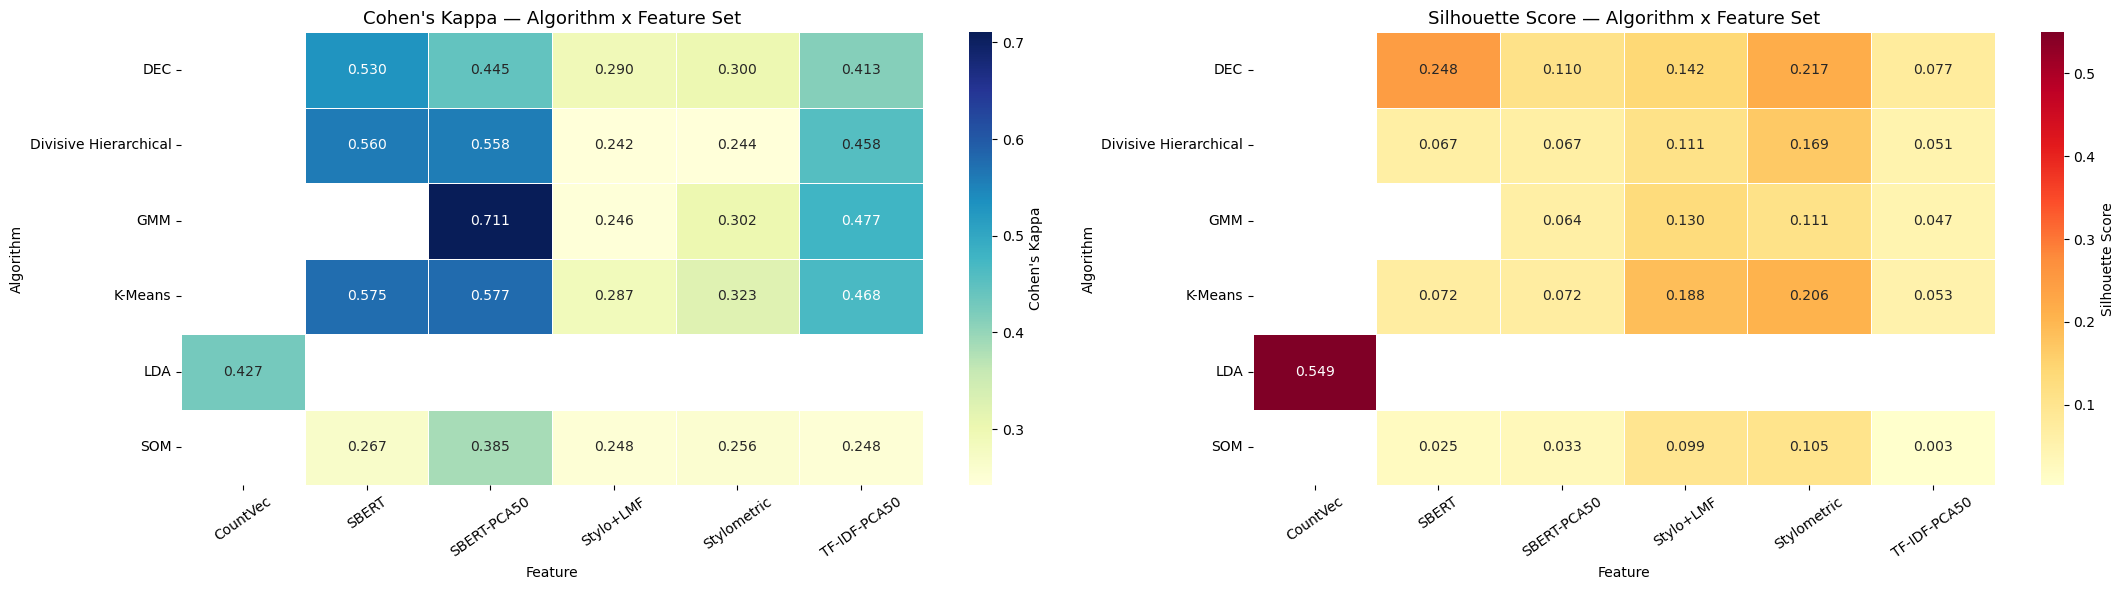

Saved: images/clustering_evaluation_heatmap.png


In [13]:
pivot_kappa = results_df.pivot_table(index='Algorithm', columns='Feature',
                                     values='Kappa', aggfunc='max')
pivot_sil   = results_df.pivot_table(index='Algorithm', columns='Feature',
                                     values='Silhouette', aggfunc='max')

fig, axes = plt.subplots(1, 2, figsize=(22, 6))
sns.heatmap(pivot_kappa, annot=True, fmt='.3f', cmap='YlGnBu', ax=axes[0],
            cbar_kws={'label': "Cohen's Kappa"}, linewidths=0.5)
axes[0].set_title("Cohen's Kappa — Algorithm x Feature Set", fontsize=13)
axes[0].tick_params(axis='x', rotation=35)

sns.heatmap(pivot_sil, annot=True, fmt='.3f', cmap='YlOrRd', ax=axes[1],
            cbar_kws={'label': 'Silhouette Score'}, linewidths=0.5)
axes[1].set_title('Silhouette Score — Algorithm x Feature Set', fontsize=13)
axes[1].tick_params(axis='x', rotation=35)

plt.tight_layout()
plt.savefig('images/clustering_evaluation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: images/clustering_evaluation_heatmap.png')

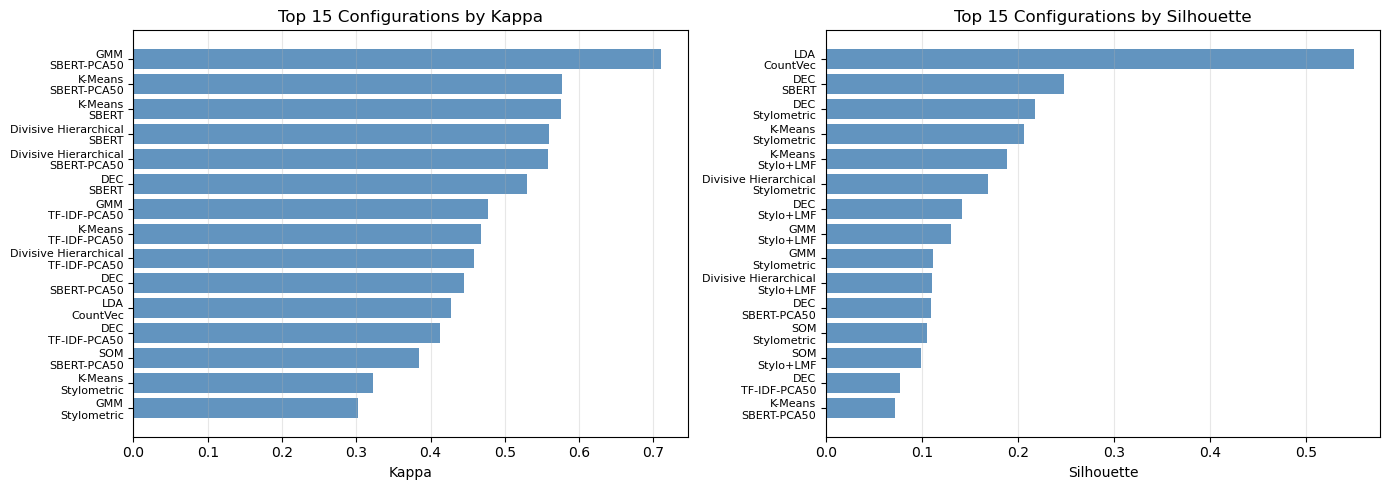

Saved: images/clustering_top15.png


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, metric in zip(axes, ['Kappa', 'Silhouette']):
    top    = results_df.dropna(subset=[metric]).sort_values(metric, ascending=False).head(15)
    labels = top['Algorithm'] + '\n' + top['Feature']
    ax.barh(range(len(top)), top[metric], color='steelblue', alpha=0.85)
    ax.set_yticks(range(len(top)))
    ax.set_yticklabels(labels, fontsize=8)
    ax.invert_yaxis()
    ax.set_xlabel(metric)
    ax.set_title(f'Top 15 Configurations by {metric}')
    ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('images/clustering_top15.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: images/clustering_top15.png')

## Error Analysis
Identifies the partitions that caused the most confusion for the best-performing model.
Shows the confusion matrix, per-genre error rates, top confusion pairs, and text snippets
for the most misclassified samples.

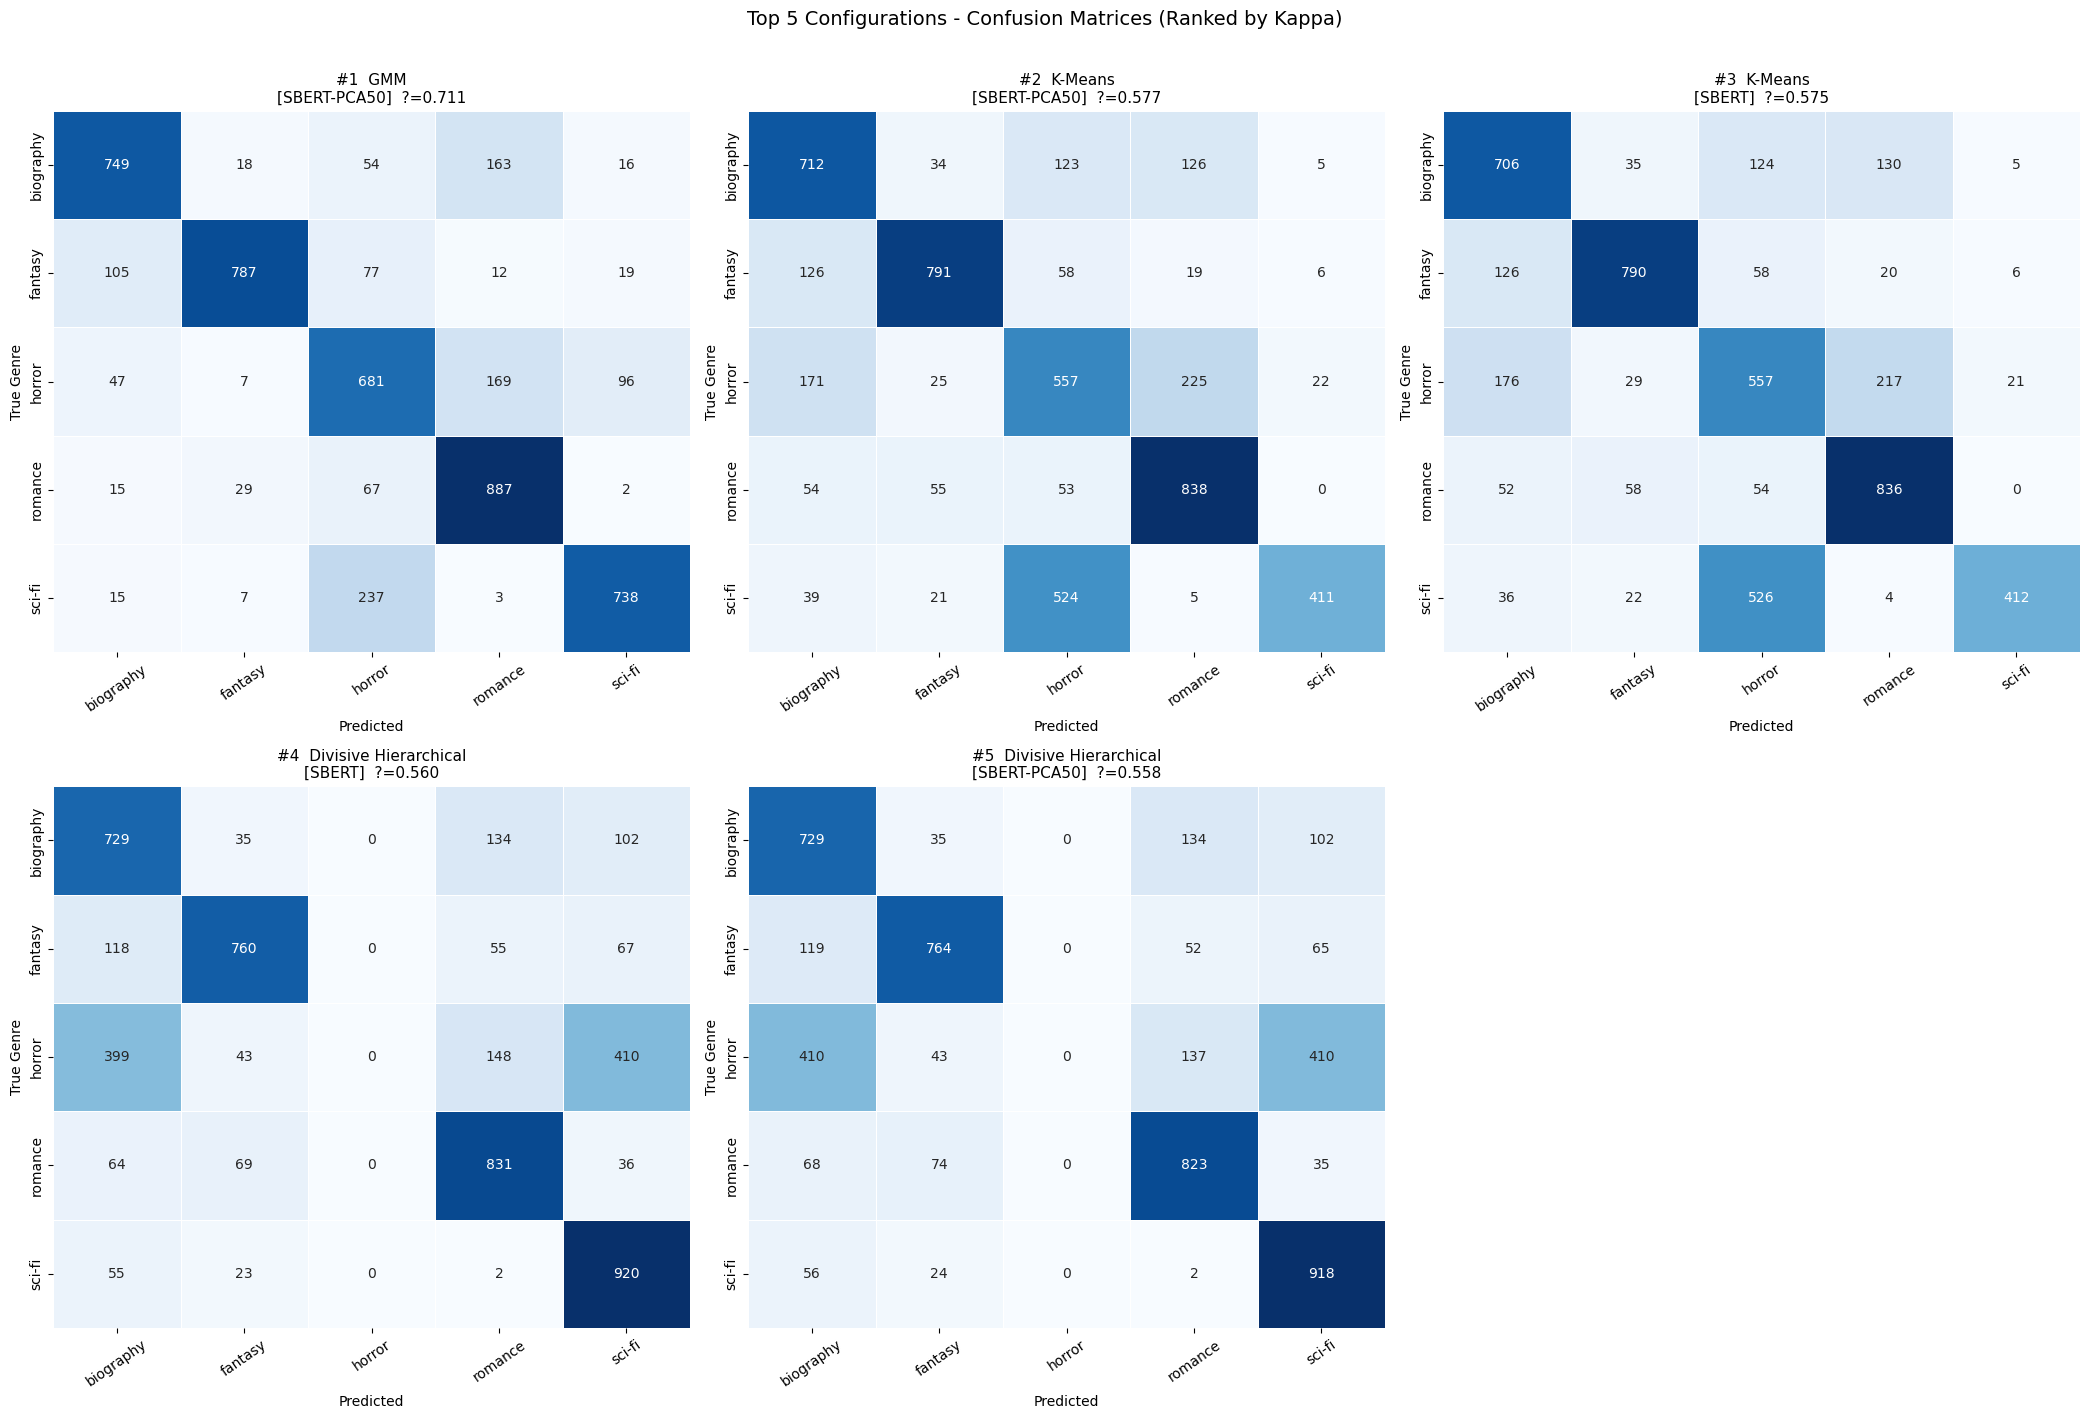

Saved: images/clustering_top5_confusion.png

Champion: GMM + SBERT-PCA50
Kappa=0.7105  Silhouette=0.0635


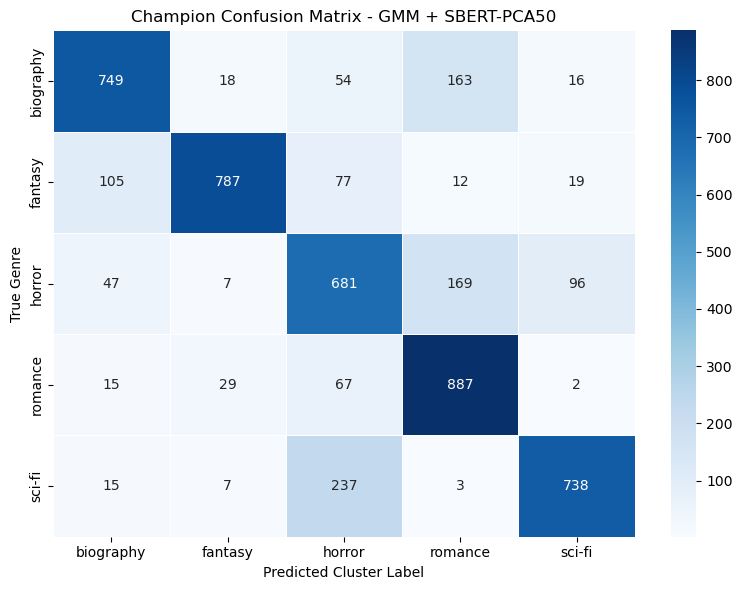

Saved: images/clustering_confusion_matrix.png


In [15]:
from sklearn.metrics import confusion_matrix

orig_df = pd.DataFrame(all_results)
top5    = results_df.nlargest(5, 'Kappa').reset_index(drop=True)

# ?? Top-5 confusion matrices (2 ? 3 grid) ????????????????????????????????????
fig, axes = plt.subplots(2, 3, figsize=(21, 14))
axes = axes.flatten()
for ax_idx, row in top5.iterrows():
    algo = row['Algorithm']
    feat = row['Feature']
    match    = orig_df.index[(orig_df['Algorithm'] == algo) &
                              (orig_df['Feature']   == feat)].tolist()
    pred_idx  = match[0] if match else 0
    _, mapped = all_preds[pred_idx]
    cm = confusion_matrix(y_true, mapped, labels=GENRES)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=GENRES, yticklabels=GENRES,
                ax=axes[ax_idx], linewidths=0.4, cbar=False)
    axes[ax_idx].set_title(f'#{ax_idx+1}  {algo}\n[{feat}]  ?={row["Kappa"]:.3f}', fontsize=11)
    axes[ax_idx].set_xlabel('Predicted')
    axes[ax_idx].set_ylabel('True Genre')
    axes[ax_idx].tick_params(axis='x', rotation=35)
axes[5].set_visible(False)
plt.suptitle('Top 5 Configurations - Confusion Matrices (Ranked by Kappa)',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('images/clustering_top5_confusion.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: images/clustering_top5_confusion.png')

# ?? Champion confusion matrix (full-size) ????????????????????????????
best_algo = results_df.loc[results_df['Kappa'].idxmax(), 'Algorithm']
best_feat = results_df.loc[results_df['Kappa'].idxmax(), 'Feature']
match     = orig_df.index[(orig_df['Algorithm'] == best_algo) &
                           (orig_df['Feature']   == best_feat)].tolist()
champ_pos = match[0] if match else 0
y_pred_best, mapped_best = all_preds[champ_pos]

print(f'\nChampion: {best_algo} + {best_feat}')
print(f'Kappa={results_df["Kappa"].max():.4f}  '
      f'Silhouette={results_df.loc[results_df["Kappa"].idxmax(), "Silhouette"]:.4f}')
cm_champ = confusion_matrix(y_true, mapped_best, labels=GENRES)
fig, ax  = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_champ, annot=True, fmt='d', cmap='Blues',
            xticklabels=GENRES, yticklabels=GENRES, ax=ax, linewidths=0.5)
ax.set_title(f'Champion Confusion Matrix - {best_algo} + {best_feat}')
ax.set_xlabel('Predicted Cluster Label')
ax.set_ylabel('True Genre')
plt.tight_layout()
plt.savefig('images/clustering_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: images/clustering_confusion_matrix.png')


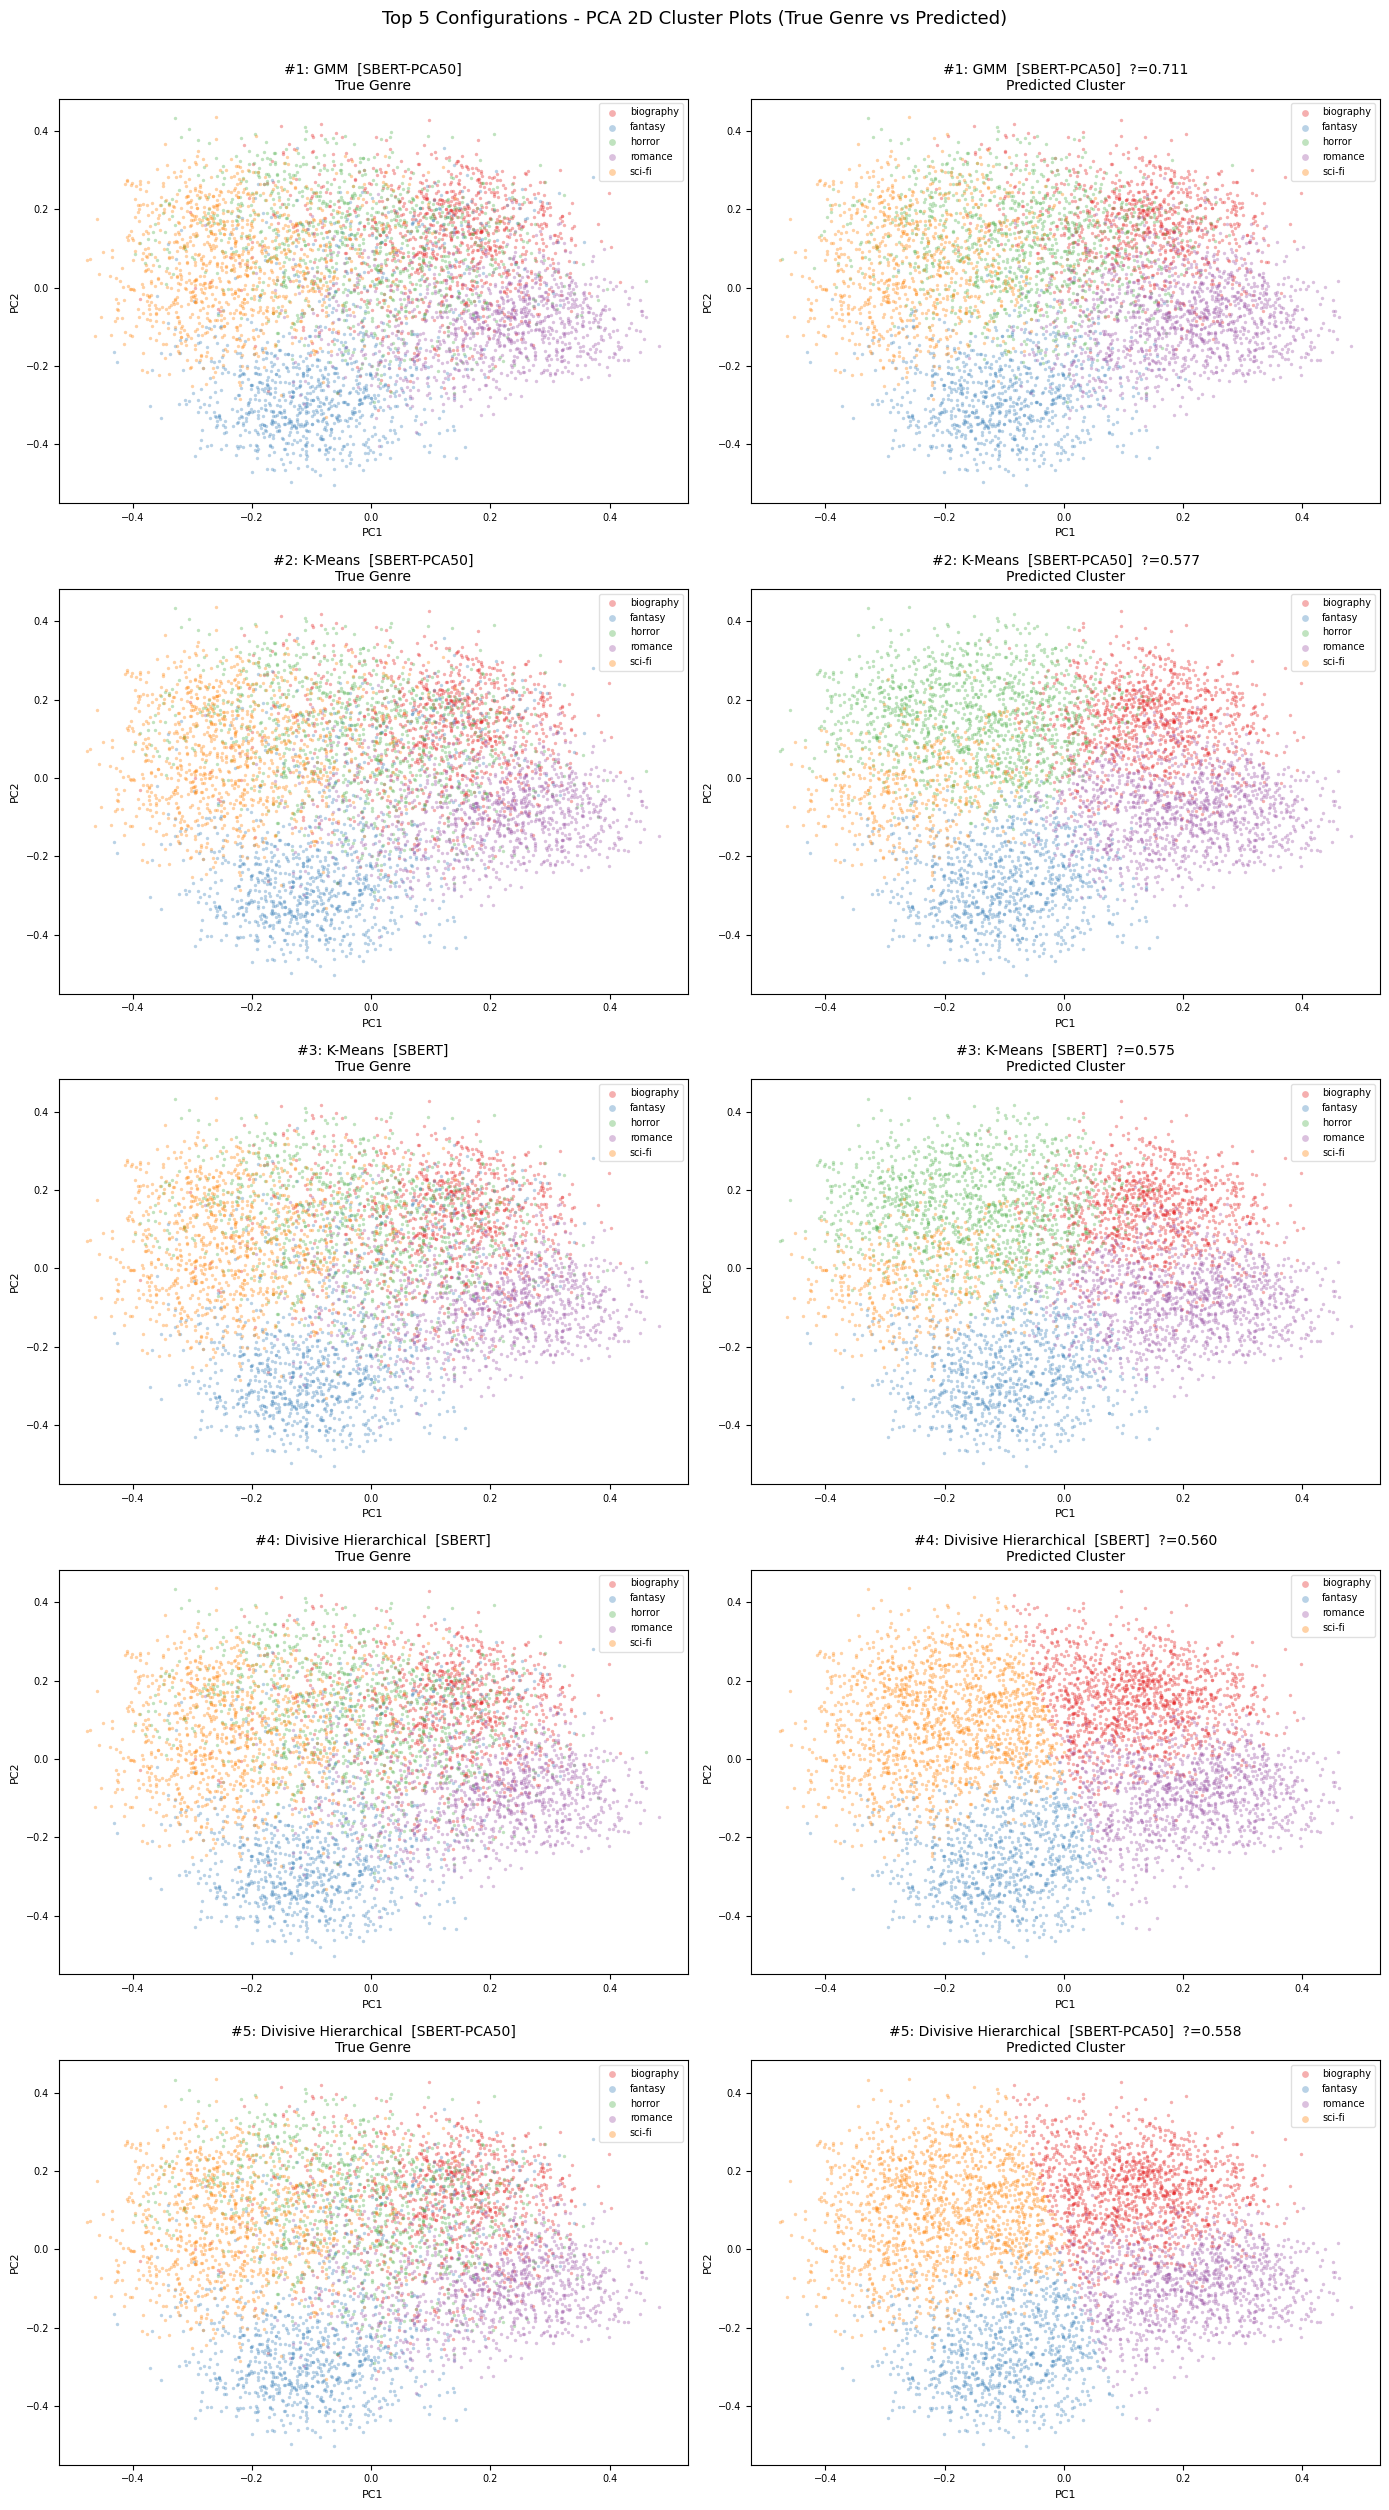

Saved: images/clustering_top5_cluster_plots.png


In [16]:
GENRE_PALETTE = {
    'biography': '#e41a1c', 'fantasy': '#377eb8', 'horror': '#4daf4a',
    'romance':   '#984ea3', 'sci-fi':  '#ff7f00', 'unknown': '#aaaaaa',
}

_feat_map = {
    'BOW':           X_bow,
    'TF-IDF':        X_tfidf,
    'Stylometric':   X_stylo,
    'LMF':           X_lmf,
    'Stylo+LMF':     X_stylo_lmf,
    'Stylo+LMF-15':  X_stylo_lmf_sel,
    'SBERT':         X_sbert,
    'TF-IDF-PCA50':  X_tfidf_pca,
    'SBERT-PCA50':   X_sbert_pca,
    'CountVec':      X_lda_probs,
}

orig_df    = pd.DataFrame(all_results)
top5       = results_df.nlargest(5, 'Kappa').reset_index(drop=True)
y_true_arr = np.array(y_true)

fig, axes = plt.subplots(5, 2, figsize=(14, 25))

for row_idx, (_, row) in enumerate(top5.iterrows()):
    algo  = row['Algorithm']
    feat  = row['Feature']
    kappa = row['Kappa']

    match    = orig_df.index[(orig_df['Algorithm'] == algo) &
                              (orig_df['Feature']   == feat)].tolist()
    pred_idx  = match[0] if match else 0
    _, mapped = all_preds[pred_idx]
    mapped    = np.array(mapped)

    X_feat = _feat_map.get(feat, X_tfidf_pca).astype(np.float64)
    X2d    = PCA(n_components=2, random_state=42).fit_transform(X_feat) \
             if X_feat.shape[1] > 2 else X_feat

    ax_l, ax_r = axes[row_idx, 0], axes[row_idx, 1]

    for genre in GENRES:
        mask = y_true_arr == genre
        ax_l.scatter(X2d[mask, 0], X2d[mask, 1],
                     c=GENRE_PALETTE[genre], label=genre,
                     alpha=0.35, s=6, linewidths=0)
    ax_l.set_title(f'#{row_idx+1}: {algo}  [{feat}]\nTrue Genre', fontsize=10)
    ax_l.legend(markerscale=2, fontsize=7, framealpha=0.6)
    ax_l.set_xlabel('PC1', fontsize=8); ax_l.set_ylabel('PC2', fontsize=8)
    ax_l.tick_params(labelsize=7)

    for genre in GENRES + ['unknown']:
        mask = mapped == genre
        if not mask.any(): continue
        ax_r.scatter(X2d[mask, 0], X2d[mask, 1],
                     c=GENRE_PALETTE.get(genre, '#aaaaaa'), label=genre,
                     alpha=0.35, s=6, linewidths=0)
    ax_r.set_title(f'#{row_idx+1}: {algo}  [{feat}]  ?={kappa:.3f}\nPredicted Cluster', fontsize=10)
    ax_r.legend(markerscale=2, fontsize=7, framealpha=0.6)
    ax_r.set_xlabel('PC1', fontsize=8); ax_r.set_ylabel('PC2', fontsize=8)
    ax_r.tick_params(labelsize=7)

plt.suptitle('Top 5 Configurations - PCA 2D Cluster Plots (True Genre vs Predicted)',
             fontsize=13, y=1.002)
plt.tight_layout()
plt.savefig('images/clustering_top5_cluster_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: images/clustering_top5_cluster_plots.png')


In [17]:
err_df = pd.DataFrame({'partition_id': part_ids, 'text': X_text,
                        'true': y_true, 'pred': list(mapped_best)})
errors = err_df[err_df['true'] != err_df['pred']]
print(f'Total misclassified: {len(errors)}/{len(partitions)} ({len(errors)/len(partitions):.1%})\n')

print('Per-genre error rate:')
for g in GENRES:
    tot = (err_df['true'] == g).sum()
    err = ((err_df['true'] == g) & (err_df['true'] != err_df['pred'])).sum()
    bar = '#' * int(20 * err / max(tot, 1))
    print(f'  {g:12}: {err:4}/{tot} ({err/tot:.1%})  {bar}')

print('\nTop 10 confusion pairs (true -> predicted):')
pairs = (errors.groupby(['true', 'pred'])
               .size()
               .reset_index(name='count')
               .sort_values('count', ascending=False))
display(pairs.head(10))

Total misclassified: 1158/5000 (23.2%)

Per-genre error rate:
  biography   :  251/1000 (25.1%)  #####
  fantasy     :  213/1000 (21.3%)  ####
  horror      :  319/1000 (31.9%)  ######
  romance     :  113/1000 (11.3%)  ##
  sci-fi      :  262/1000 (26.2%)  #####

Top 10 confusion pairs (true -> predicted):


,true,pred,count
18,sci-fi,horror,237
10,horror,romance,169
2,biography,romance,163
4,fantasy,biography,105
11,horror,sci-fi,96
5,fantasy,horror,77
14,romance,horror,67
1,biography,horror,54
8,horror,biography,47
13,romance,fantasy,29


In [18]:
print('Sample misclassified partitions (2 per genre):')
for g in GENRES:
    subset = errors[errors['true'] == g].head(2)
    if subset.empty:
        continue
    print(f'\n  [{g.upper()}]')
    for _, row in subset.iterrows():
        print(f'    Predicted : {row["pred"]}')
        print(f'    ID        : {row["partition_id"]}')
        print(f'    Snippet   : {row["text"][:200]}...')

Sample misclassified partitions (2 per genre):

  [BIOGRAPHY]
    Predicted : romance
    ID        : AutobiographyOfBenjaminFranklin_partition_l
    Snippet   : writing. Hereby, too, I shall indulge the inclination so natural in old men, to be talking of themselves and their own past actions; and I shall indulge it without being tiresome to others, who, throu...
    Predicted : romance
    ID        : AutobiographyOfBenjaminFranklin_partition_o
    Snippet   : accounts of their disposition, and would have drawn me on again; but I declared absolutely my resolution to have nothing more to do with that family. This was resented by the Godfreys; we differed, an...

  [FANTASY]
    Predicted : horror
    ID        : TheWonderfulWizardOfOz_partition_eg
    Snippet   : the wall. When they were all sitting in a row on the top of the wall, they looked down and saw a strange sight. Before them was a great stretch of country having a floor as smooth and shining and whit...
    Predicted : horror

## Diagnostic — Horror Cluster Distribution
Investigates why LDA and Divisive Hierarchical show 0 horror predictions.
For each affected algorithm, shows how horror partitions are spread across clusters
and which genre each cluster was majority-mapped to.

In [19]:
y_true_arr = np.array(y_true)
orig_df    = pd.DataFrame(all_results)

investigate = ['LDA', 'Divisive Hierarchical']

for algo in investigate:
    print('=' * 65)
    print(f'ALGORITHM: {algo}')
    print('=' * 65)

    # All entries for this algorithm
    algo_rows = orig_df[orig_df['Algorithm'] == algo]

    for _, res_row in algo_rows.iterrows():
        feat     = res_row['Feature']
        pred_idx = orig_df.index[(orig_df['Algorithm'] == algo) &
                                  (orig_df['Feature']   == feat)].tolist()[0]
        y_pred_raw, y_pred_mapped = all_preds[pred_idx]

        # Cluster -> majority genre mapping
        cluster_ids = np.unique(y_pred_raw)
        mapping = {cid: Counter(y_true_arr[y_pred_raw == cid]).most_common(1)[0][0]
                   for cid in cluster_ids if (y_pred_raw == cid).sum() > 0}

        # How horror partitions are distributed across clusters
        horror_mask    = y_true_arr == 'horror'
        horror_clusters = y_pred_raw[horror_mask]
        horror_dist    = Counter(horror_clusters)

        print(f'\n  Feature: {feat}  |  Kappa={res_row["Kappa"]:.4f}')
        print(f'  Cluster -> Mapped Genre:')
        for cid in sorted(mapping):
            size = (y_pred_raw == cid).sum()
            print(f'    Cluster {cid}: {mapping[cid]:12}  ({size} partitions)')

        print(f'\n  Horror partitions ({horror_mask.sum()}) spread across clusters:')
        for cid, cnt in sorted(horror_dist.items(), key=lambda x: -x[1]):
            mapped_to = mapping.get(cid, '?')
            pct       = cnt / horror_mask.sum() * 100
            bar       = '#' * int(pct / 2)
            print(f'    Cluster {cid} -> "{mapped_to:12}" : {cnt:4} ({pct:.1f}%)  {bar}')

        # Check if any cluster was majority horror
        horror_majority = [cid for cid, g in mapping.items() if g == 'horror']
        if horror_majority:
            print(f'  ✓ "horror" WAS assigned to cluster(s): {horror_majority}')
        else:
            print(f'  ✗ "horror" was NOT the majority in any cluster — hence 0 in confusion matrix')
    print()

ALGORITHM: LDA

  Feature: CountVec  |  Kappa=0.4275
  Cluster -> Mapped Genre:
    Cluster 0: sci-fi        (395 partitions)
    Cluster 1: biography     (1128 partitions)
    Cluster 2: fantasy       (1443 partitions)
    Cluster 3: romance       (390 partitions)
    Cluster 4: romance       (1644 partitions)

  Horror partitions (1000) spread across clusters:
    Cluster 4 -> "romance     " :  525 (52.5%)  ##########################
    Cluster 1 -> "biography   " :  186 (18.6%)  #########
    Cluster 2 -> "fantasy     " :  162 (16.2%)  ########
    Cluster 3 -> "romance     " :  126 (12.6%)  ######
    Cluster 0 -> "sci-fi      " :    1 (0.1%)  
  ✗ "horror" was NOT the majority in any cluster — hence 0 in confusion matrix

ALGORITHM: Divisive Hierarchical

  Feature: SBERT  |  Kappa=0.5600
  Cluster -> Mapped Genre:
    Cluster 0: biography     (1365 partitions)
    Cluster 1: fantasy       (930 partitions)
    Cluster 2: romance       (1170 partitions)
    Cluster 3: sci-fi      

## Top 20 Frequent Words and Collocations per Cluster
For each cluster (labeled by majority-vote genre), extracts the 20 most frequent
unigrams and bigrams. Useful for interpreting what textual signals each cluster has captured.

In [20]:
mapped_arr = np.array(mapped_best)

print('Top 20 words / collocations per cluster\n')
for genre_name in GENRES:
    mask = mapped_arr == genre_name
    if not mask.any():
        print(f'[{genre_name}] — no samples assigned\n')
        continue
    texts_c = [X_text[i] for i in range(len(X_text)) if mask[i]]
    cv_t    = CountVectorizer(stop_words='english', ngram_range=(1, 2),
                              max_features=20000, min_df=1)
    X_t     = cv_t.fit_transform(texts_c)
    vocab_t = cv_t.get_feature_names_out()
    freq_t  = np.asarray(X_t.sum(axis=0)).flatten()
    top20   = freq_t.argsort()[::-1][:20]

    true_counts  = Counter(np.array(y_true)[mask])
    purity       = true_counts.most_common(1)[0][1] / mask.sum()
    dominant     = true_counts.most_common(1)[0][0]

    print(f'Cluster -> "{genre_name.upper()}"  ({mask.sum()} partitions, '
          f'purity={purity:.1%}, dominant true genre="{dominant}")')
    term_df = pd.DataFrame([(vocab_t[i], int(freq_t[i])) for i in top20],
                           columns=['term', 'count'])
    term_df.index += 1
    display(term_df)
    print()

Top 20 words / collocations per cluster

Cluster -> "BIOGRAPHY"  (931 partitions, purity=80.5%, dominant true genre="biography")


,term,count
1,time,913
2,great,769
3,mr,735
4,prince,638
5,man,595
6,did,522
7,little,512
8,years,509
9,new,493
10,royal,484



Cluster -> "FANTASY"  (848 partitions, purity=92.8%, dominant true genre="fantasy")


,term,count
1,said,4365
2,alice,2462
3,little,1360
4,went,932
5,came,909
6,like,837
7,queen,803
8,know,791
9,thought,761
10,king,751



Cluster -> "HORROR"  (1116 partitions, purity=61.0%, dominant true genre="horror")


,term,count
1,said,1154
2,time,1037
3,man,928
4,came,784
5,like,734
6,little,676
7,great,654
8,did,626
9,thought,534
10,saw,532



Cluster -> "ROMANCE"  (1234 partitions, purity=71.9%, dominant true genre="romance")


,term,count
1,said,1316
2,mr,1115
3,did,996
4,romeo,983
5,shall,948
6,love,870
7,know,861
8,time,860
9,good,847
10,thou,835



Cluster -> "SCI-FI"  (871 partitions, purity=84.7%, dominant true genre="sci-fi")


,term,count
1,said,1044
2,strong,870
3,captain,839
4,tom,773
5,dane,676
6,ship,663
7,did,591
8,man,553
9,like,542
10,men,529
